In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import pickle

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rodda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rodda\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
df = pd.read_csv("customer_support_tickets.csv")

In [4]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [5]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [6]:
df = df[['Ticket Description',
         'Ticket Type',
         'Ticket Priority']]

In [7]:
df.columns = ['text',
              'category',
              'priority']

In [8]:
df.head()

,text,category,priority
0,I'm having an issue with the {product_purchase...,Technical issue,Critical
1,I'm having an issue with the {product_purchase...,Technical issue,Critical
2,I'm facing a problem with my {product_purchase...,Technical issue,Low
3,I'm having an issue with the {product_purchase...,Billing inquiry,Low
4,I'm having an issue with the {product_purchase...,Billing inquiry,Low


In [9]:
df.isnull().sum()

text        0
category    0
priority    0
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
df.isnull().sum()

text        0
category    0
priority    0
dtype: int64

In [12]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()

    words = [word for word in words
             if word not in stop_words]

    words = [lemmatizer.lemmatize(word)
             for word in words]

    return " ".join(words)

In [13]:
df['clean_text'] = df['text'].apply(clean_text)

In [14]:
df[['text','clean_text']].head()

,text,clean_text
0,I'm having an issue with the {product_purchase...,im issue productpurchased please assistyour bi...
1,I'm having an issue with the {product_purchase...,im issue productpurchased please assistif need...
2,I'm facing a problem with my {product_purchase...,im facing problem productpurchased productpurc...
3,I'm having an issue with the {product_purchase...,im issue productpurchased please assistif prob...
4,I'm having an issue with the {product_purchase...,im issue productpurchased please assistnote se...


In [15]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])

In [38]:
print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (8469, 5000)


In [17]:
y = df['category']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [20]:
y_pred = model.predict(X_test)

In [21]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.20070838252656434


In [22]:
print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

     Billing inquiry       0.17      0.11      0.13       357
Cancellation request       0.22      0.26      0.24       327
     Product inquiry       0.19      0.18      0.19       316
      Refund request       0.18      0.21      0.20       345
     Technical issue       0.23      0.24      0.24       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



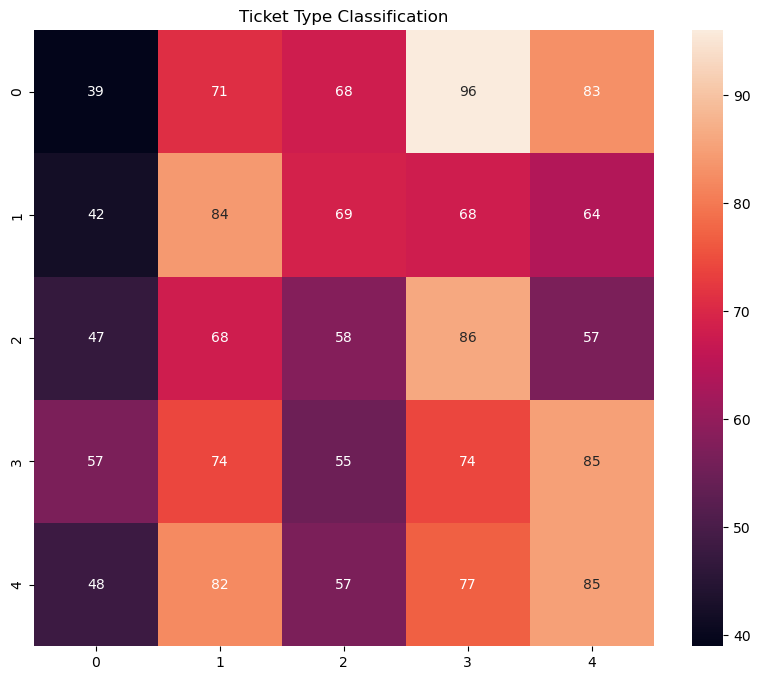

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Ticket Type Classification")
plt.show()

In [24]:
y_priority = df['priority']

In [25]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X,
    y_priority,
    test_size=0.2,
    random_state=42
)

In [26]:
priority_model = LogisticRegression(max_iter=1000)

priority_model.fit(X_train2, y_train2)

LogisticRegression(max_iter=1000)

In [27]:
priority_pred = priority_model.predict(X_test2)

In [28]:
priority_accuracy = accuracy_score(
    y_test2,
    priority_pred
)

print("Priority Accuracy:",
      priority_accuracy)

Priority Accuracy: 0.2532467532467532


In [29]:
print(
    classification_report(
        y_test2,
        priority_pred
    )
)

              precision    recall  f1-score   support

    Critical       0.23      0.24      0.23       411
        High       0.27      0.28      0.27       409
         Low       0.25      0.24      0.25       415
      Medium       0.27      0.25      0.26       459

    accuracy                           0.25      1694
   macro avg       0.25      0.25      0.25      1694
weighted avg       0.25      0.25      0.25      1694



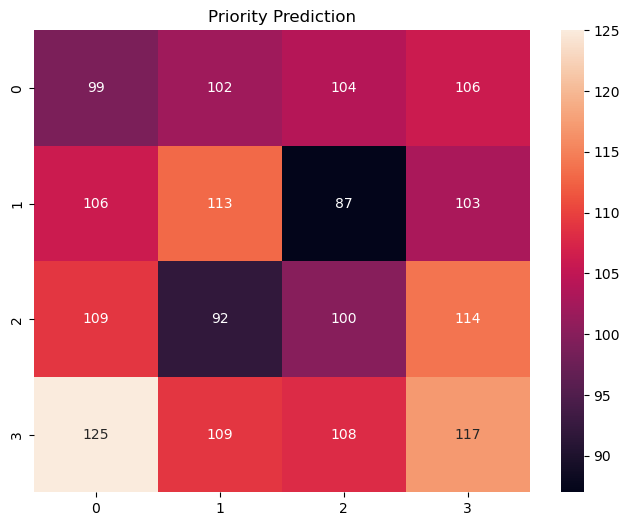

In [30]:
cm2 = confusion_matrix(
    y_test2,
    priority_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm2,
    annot=True,
    fmt='d'
)

plt.title("Priority Prediction")
plt.show()

In [31]:
print(df['category'].unique())

['Technical issue' 'Billing inquiry' 'Cancellation request'
 'Product inquiry' 'Refund request']


In [32]:
print(df['priority'].unique())

['Critical' 'Low' 'High' 'Medium']


In [33]:
sample_ticket = [
    "I was charged twice for my subscription."
]

sample_vector = vectorizer.transform(
    sample_ticket
)

category = model.predict(
    sample_vector
)

priority = priority_model.predict(
    sample_vector
)

print("Category:", category[0])
print("Priority:", priority[0])

Category: Product inquiry
Priority: Low


In [34]:
sample_ticket = [
    "My account is locked and I cannot login."
]

sample_vector = vectorizer.transform(
    sample_ticket
)

print(
    model.predict(sample_vector)[0]
)

print(
    priority_model.predict(
        sample_vector
    )[0]
)

Billing inquiry
High


In [39]:
pickle.dump(
    model,
    open(
        "category_model.pkl",
        "wb"
    )
)

In [36]:
pickle.dump(
    priority_model,
    open(
        "priority_model.pkl",
        "wb"
    )
)

In [37]:
pickle.dump(
    vectorizer,
    open(
        "vectorizer.pkl",
        "wb"
    )
)

In [40]:
import os

for file in os.listdir():
    if file.endswith(".pkl"):
        print(file)

category_model.pkl
priority_model.pkl
vectorizer.pkl


In [41]:
import os

print(os.path.exists("vectorizer.pkl"))
print(os.path.exists("category_model.pkl"))
print(os.path.exists("priority_model.pkl"))

True
True
True


In [42]:
import pickle

vectorizer = pickle.load(open("vectorizer.pkl", "rb"))

category_model = pickle.load(open("category_model.pkl", "rb"))

priority_model = pickle.load(open("priority_model.pkl", "rb"))

In [43]:
sample_ticket = ["My account is locked"]

sample_vector = vectorizer.transform(sample_ticket)

print("Category:",
      category_model.predict(sample_vector)[0])

print("Priority:",
      priority_model.predict(sample_vector)[0])

Category: Billing inquiry
Priority: Critical
